In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.to_csv("data/titanic_raw.csv", index=False)
df.shape

(891, 12)

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df_raw = df.copy()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.duplicated().sum()

np.int64(0)

## Initial Data Inspection

- Dataset has 891 rows and 12 columns
- **Age**: 177 missing values (~20%)
- **Cabin**: 687 missing values (~77%)
- **Embarked**: 2 missing values
- No duplicate rows found
- Fare ranges from 0 to 512.33, with a mean of ~32.20

### Cleaning Step 1: Extract Title from Name
Names contain a title (Mr, Mrs, Miss, etc.) which is a strong hint about age and social status. 
I'll extract it so it can help fill in missing ages more accurately than a single overall average.

In [9]:
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
rare = ["Dr","Rev","Col","Major","Capt","Countess","Lady","Sir","Don","Jonkheer","Dona"]
df["Title"] = df["Title"].replace(rare, "Rare")
df["Title"].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

### Cleaning Step 2: Fill Missing Age
Age is missing for ~20% of passengers. Instead of using one overall average (which would treat a young 
"Master" the same as an adult "Mr"), I filled missing ages with the median age of their Title group. 
I also added an Age_Missing flag to record which values were estimated.

In [10]:
df["Age_Missing"] = df["Age"].isnull().astype(int)
df["Age"] = df["Age"].fillna(df.groupby("Title")["Age"].transform("median"))
df["Age"].isnull().sum()

np.int64(0)

### Cleaning Step 3: Fill Missing Embarked
Only 2 rows are missing the port of embarkation. I filled these with the most common port (the mode), 
since the impact of 2 rows is negligible either way.

In [11]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Embarked"].isnull().sum()

np.int64(0)

### Cleaning Step 4: Handle Cabin
Cabin is missing for 77% of passengers, too much to reliably impute. Instead, I extracted the deck letter 
(first character of the cabin code) and a Has_Cabin flag (whether a cabin was recorded at all), then 
dropped the original Cabin column. Having a recorded cabin likely reflects a wealthier passenger.

In [12]:
df["Has_Cabin"] = df["Cabin"].notnull().astype(int)
df["Deck"] = df["Cabin"].str[0].fillna("Unknown")
df = df.drop(columns=["Cabin"])
df[["Has_Cabin", "Deck"]].head()

,Has_Cabin,Deck
0,0,Unknown
1,1,C
2,0,Unknown
3,1,C
4,0,Unknown


### Cleaning Step 5: Feature Engineering
Created three new features to help capture patterns the raw columns don't show directly:
- FamilySize: total family members aboard (SibSp + Parch + self)
- IsAlone: whether the passenger was traveling alone
- AgeGroup: age bucketed into Child, Teen, Adult, Middle-aged, Senior

In [13]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100],
                        labels=["Child", "Teen", "Adult", "Middle-aged", "Senior"])
df[["FamilySize", "IsAlone", "AgeGroup"]].head()

,FamilySize,IsAlone,AgeGroup
0,2,0,Adult
1,2,0,Middle-aged
2,1,1,Adult
3,2,0,Adult
4,1,1,Adult


### Final Check and Save
Confirming no missing values remain (apart from intentional drops), then saving the cleaned dataset.

In [14]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Title          0
Age_Missing    0
Has_Cabin      0
Deck           0
FamilySize     0
IsAlone        0
AgeGroup       0
dtype: int64

In [15]:
df.to_csv("data/titanic_cleaned.csv", index=False)
print("Saved cleaned dataset with shape:", df.shape)

Saved cleaned dataset with shape: (891, 18)


## Data Visualizations

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

### Chart 1: Survival Rate by Class and Gender

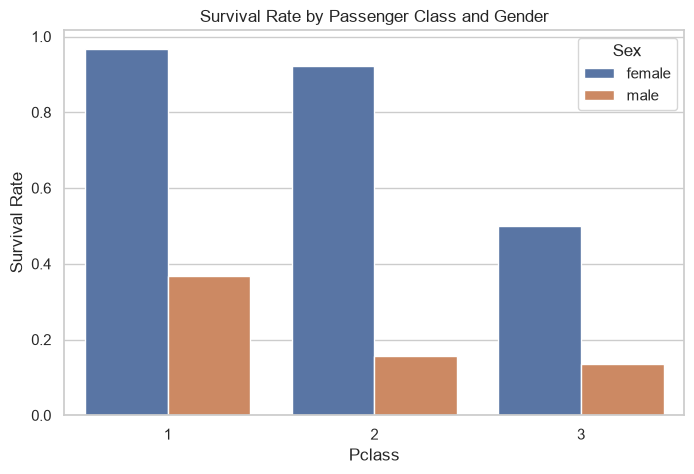

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex", errorbar=None)
plt.title("Survival Rate by Passenger Class and Gender")
plt.ylabel("Survival Rate")
plt.savefig("images/survival_by_class_gender.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 2: Age Distribution

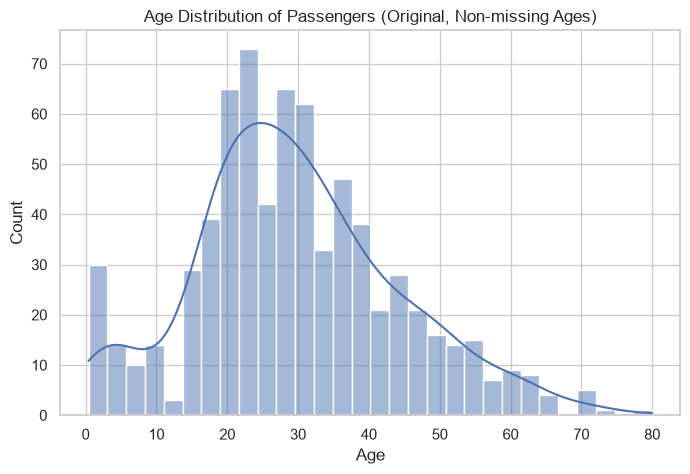

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df_raw["Age"].dropna(), bins=30, kde=True)
plt.title("Age Distribution of Passengers (Original, Non-missing Ages)")
plt.xlabel("Age")
plt.savefig("images/age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 3: Correlation Heatmap

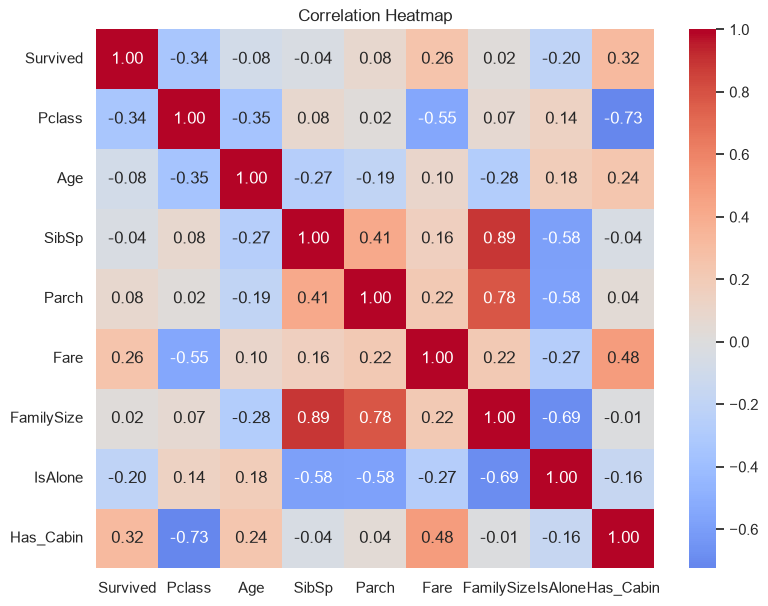

In [19]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone", "Has_Cabin"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Findings

In [20]:
print("Survival by Sex:\n", df.groupby("Sex")["Survived"].mean(), "\n")
print("Survival by Pclass:\n", df.groupby("Pclass")["Survived"].mean(), "\n")
print("Survival by AgeGroup:\n", df.groupby("AgeGroup", observed=True)["Survived"].mean(), "\n")
print("Survival by IsAlone:\n", df.groupby("IsAlone")["Survived"].mean())

Survival by Sex:
 Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64 

Survival by Pclass:
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64 

Survival by AgeGroup:
 AgeGroup
Child          0.575342
Teen           0.428571
Adult          0.352830
Middle-aged    0.397959
Senior         0.227273
Name: Survived, dtype: float64 

Survival by IsAlone:
 IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64


## Observations

1. **Gender was the strongest survival factor.** Women survived at 74.2%, compared to just 18.9% for 
men — a gap of over 55 percentage points. This reflects a "women and children first" evacuation 
policy, and means Sex should be a primary feature in any predictive model.

2. **Passenger class strongly predicted survival.** 1st class passengers survived at 63.0%, 2nd class 
at 47.3%, and 3rd class at only 24.2%. This likely reflects cabin proximity to lifeboats and possible 
boarding priority for wealthier passengers — confirmed by the heatmap, where Pclass correlates 
negatively with survival (-0.34) and Fare correlates positively (+0.26).

3. **Children had a survival advantage, which declined with age.** Children survived at 57.5%, the 
highest of any age group, while Seniors survived at only 22.7% — the lowest. This is consistent 
with the "women and children first" pattern seen in the gender breakdown.

4. **Traveling alone reduced survival odds.** Passengers who were alone survived at 30.4%, compared 
to 50.6% for those with family aboard. A small family group could help each other reach lifeboats, 
while solo travelers may have had less support during the evacuation.

## Conclusion

This analysis shows that survival on the Titanic was driven primarily by gender, passenger class, and 
age, consistent with a "women and children first" evacuation policy that also favored wealthier 
passengers with better access to lifeboats. The dataset required moderate cleaning — median age 
imputation by title, mode imputation for Embarked, and converting the largely-missing Cabin column 
into Has_Cabin and Deck features. A natural next step would be training a classification model 
(e.g. logistic regression or decision tree) using Sex, Pclass, Age, and FamilySize as the primary features.